# Compare Scan And Fixed AUT EEC Results

This notebook reads the saved scan-summary results and overlays them with the fixed `a=0.10, b=0.10` prediction for both SIDIS/EIC and `ee`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


In [2]:
results_dir_scan = Path("AUT_EEC_EIC_noLQCD")
results_dir_fixed = Path("AUT_EEC_EIC_noLQCD")

fit_order = "LO"
coeffs = (0.1, 0.1)
scan_label = "a_b_uniform_area_100"

sidis_x_q_map = {
    0.01: [2.0, 7.0],
    0.1: [2.0, 8.5],
    0.3: [2.0, 10.0],
}

ee_chibar_deg_list = [1, 15, 30]
ee_Q_list = [3.65, 10.58]

label_scan = "scan"
label_fixed = "a=0.10, b=0.10"


In [3]:
def _format_q_label(Q):
    Q = float(Q)
    if Q.is_integer():
        return str(int(Q))
    return f"{Q:g}".replace('.', 'p')


def _candidate_paths(*paths):
    out = []
    for path in paths:
        if path not in out:
            out.append(path)
    return out


def sidis_fixed_paths(results_dir, a, b, x, Q, fit_order="LO"):
    return _candidate_paths(
        results_dir / f"AUT_EEC_SIDIS_a{a:.2f}_b{b:.2f}_x{x:.2f}_Q{_format_q_label(Q)}_{fit_order}.xlsx",
        results_dir / f"AUT_EEC_SIDIS_a{a:.2f}_b{b:.2f}_x{x:.2f}_Q{int(Q)}_{fit_order}.xlsx",
    )


def ee_fixed_paths(results_dir, a, b, chibar_deg, Q, fit_order="LO"):
    return _candidate_paths(
        results_dir / f"AUT_EEC_epem_a{a:.2f}_b{b:.2f}_chibar{int(chibar_deg)}_Q{int(Q)}_{fit_order}.xlsx",
        results_dir / f"AUT_EEC_epem_a{a:.2f}_b{b:.2f}_chibar{int(chibar_deg)}_Q{_format_q_label(Q)}_{fit_order}.xlsx",
    )


def sidis_scan_paths(results_dir, scan_label, x, Q, fit_order="LO"):
    return _candidate_paths(
        results_dir / f"AUT_EEC_SIDIS_scan_{scan_label}_x{x:.2f}_Q{_format_q_label(Q)}_{fit_order}.xlsx",
        results_dir / f"AUT_EEC_SIDIS_scan_{scan_label}_x{x:.2f}_Q{int(Q)}_{fit_order}.xlsx",
    )


def ee_scan_paths(results_dir, scan_label, chibar_deg, Q, fit_order="LO"):
    return _candidate_paths(
        results_dir / f"AUT_EEC_epem_scan_{scan_label}_chibar{int(chibar_deg)}_Q{_format_q_label(Q)}_{fit_order}.xlsx",
        results_dir / f"AUT_EEC_epem_scan_{scan_label}_chibar{int(chibar_deg)}_Q{int(Q)}_{fit_order}.xlsx",
    )


def _load_excel(paths):
    for path in paths:
        if path.exists():
            return pd.read_excel(path)
    raise FileNotFoundError(paths[0])


def load_sidis_fixed_df(results_dir, coeffs, x, Q, fit_order="LO"):
    return _load_excel(sidis_fixed_paths(results_dir, coeffs[0], coeffs[1], x, Q, fit_order))


def load_ee_fixed_df(results_dir, coeffs, chibar_deg, Q, fit_order="LO"):
    return _load_excel(ee_fixed_paths(results_dir, coeffs[0], coeffs[1], chibar_deg, Q, fit_order))


def load_sidis_scan_df(results_dir, scan_label, x, Q, fit_order="LO"):
    return _load_excel(sidis_scan_paths(results_dir, scan_label, x, Q, fit_order))


def load_ee_scan_df(results_dir, scan_label, chibar_deg, Q, fit_order="LO"):
    return _load_excel(ee_scan_paths(results_dir, scan_label, chibar_deg, Q, fit_order))


def _extract_curve(df):
    chi = np.asarray(df["CHI"], dtype=float)
    central = np.asarray(df["AUT_central"] if "AUT_central" in df else df["AUT_mean"], dtype=float)
    std = np.asarray(df["AUT_std"], dtype=float) if "AUT_std" in df else np.zeros_like(central)
    return chi, central, std


def _set_padded_ylim(ax, curves, pad_frac=0.08):
    values = []
    for _, central, std in curves:
        values.append(np.asarray(central, dtype=float) - np.asarray(std, dtype=float))
        values.append(np.asarray(central, dtype=float) + np.asarray(std, dtype=float))

    if not values:
        return

    ymin = float(np.nanmin([np.nanmin(v) for v in values]))
    ymax = float(np.nanmax([np.nanmax(v) for v in values]))

    if not np.isfinite(ymin) or not np.isfinite(ymax):
        return

    if np.isclose(ymin, ymax):
        pad = 0.05 * max(1.0, abs(ymin))
    else:
        pad = pad_frac * (ymax - ymin)

    ax.set_ylim(ymin - pad, ymax + pad)


def _build_panel_figure(ncols):
    fig = plt.figure(figsize=(5 * ncols, 6.2), constrained_layout=True)
    grid = fig.add_gridspec(3, ncols, height_ratios=[0.18, 0.22, 1.0])
    global_ax = fig.add_subplot(grid[0, :])
    header_axes = np.array([fig.add_subplot(grid[1, i]) for i in range(ncols)])
    data_axes = np.array([fig.add_subplot(grid[2, i]) for i in range(ncols)])

    for ax in np.concatenate(([global_ax], header_axes)):
        ax.set_axis_off()
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)

    return fig, global_ax, header_axes, data_axes


def _draw_global_header(ax, title, *, include_q=False, q_values=None, colors=None):
    ax.text(0.5, 0.78, title, ha="center", va="center", fontsize=17)
    ax.text(0.5, 0.46, f"solid = {label_scan}, dashed = {label_fixed}", ha="center", va="center", fontsize=11)
    if include_q and q_values is not None and colors is not None:
        _draw_q_key(ax, q_values, colors, y=0.14)


def _draw_header_title(ax, title):
    ax.text(0.5, 0.74, title, ha="center", va="center", fontsize=15)


def _draw_q_key(ax, q_values, colors, *, y=0.24):
    if not q_values:
        return

    if len(q_values) == 1:
        starts = np.array([0.34])
    elif len(q_values) == 2:
        starts = np.array([0.20, 0.58])
    else:
        starts = np.linspace(0.08, 0.64, len(q_values))

    for x0, Q, color in zip(starts, q_values, colors):
        ax.plot(
            [x0, x0 + 0.08],
            [y, y],
            color=color,
            linewidth=2.4,
            solid_capstyle="round",
            clip_on=False,
        )
        ax.text(x0 + 0.10, y, f"Q={Q:g}", ha="left", va="center", fontsize=11)


def _plot_pair(ax, chi, central_scan, std_scan, central_fixed, std_fixed, *, color):
    ax.plot(chi, central_scan, color=color, linestyle="-", linewidth=2.0)
    ax.fill_between(chi, central_scan - std_scan, central_scan + std_scan, color=color, alpha=0.20)

    ax.plot(chi, central_fixed, color=color, linestyle="--", linewidth=2.0)
    ax.fill_between(chi, central_fixed - std_fixed, central_fixed + std_fixed, color=color, alpha=0.08)


def plot_sidis_scan_vs_fixed(*, x_q_map, coeffs, scan_label, fit_order="LO"):
    x_values = [float(x) for x in x_q_map.keys()]
    fig, global_ax, header_axes, axes = _build_panel_figure(len(x_values))
    color_arr = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:brown"]

    _draw_global_header(
        global_ax,
        f"SIDIS AUT EEC: scan vs a={coeffs[0]:.2f}, b={coeffs[1]:.2f}, {fit_order}",
    )

    for header_ax, ax, x in zip(header_axes, axes, x_values):
        curves = []
        q_values = [float(Q) for Q in x_q_map[x]]
        colors = color_arr[:len(q_values)]

        for color, Q in zip(colors, q_values):
            df_scan = load_sidis_scan_df(results_dir_scan, scan_label, x, Q, fit_order)
            df_fixed = load_sidis_fixed_df(results_dir_fixed, coeffs, x, Q, fit_order)

            chi_scan, central_scan, std_scan = _extract_curve(df_scan)
            chi_fixed, central_fixed, std_fixed = _extract_curve(df_fixed)

            if chi_scan.shape != chi_fixed.shape or not np.allclose(chi_scan, chi_fixed):
                raise ValueError(f"CHI grid mismatch for x={x}, Q={Q:g}")

            _plot_pair(ax, chi_scan, central_scan, std_scan, central_fixed, std_fixed, color=color)
            curves.extend([
                (chi_scan, central_scan, std_scan),
                (chi_fixed, central_fixed, std_fixed),
            ])

        _draw_header_title(header_ax, f"x={x:g}")
        _draw_q_key(header_ax, q_values, colors, y=0.20)
        _set_padded_ylim(ax, curves)
        ax.set_xlabel("chi [deg]")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("AUT EEC(chi)")
    plt.show()


def plot_ee_scan_vs_fixed(*, chibar_deg_list, Q_list, coeffs, scan_label, fit_order="LO"):
    chibar_values = [float(chibar_deg) for chibar_deg in chibar_deg_list]
    q_values = [float(Q) for Q in Q_list]
    colors = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:brown"][:len(q_values)]
    fig, global_ax, header_axes, axes = _build_panel_figure(len(chibar_values))

    _draw_global_header(
        global_ax,
        f"ee AUT EEC: scan vs a={coeffs[0]:.2f}, b={coeffs[1]:.2f}, {fit_order}",
        include_q=True,
        q_values=q_values,
        colors=colors,
    )

    for header_ax, ax, chibar_deg in zip(header_axes, axes, chibar_values):
        curves = []

        for color, Q in zip(colors, q_values):
            df_scan = load_ee_scan_df(results_dir_scan, scan_label, chibar_deg, Q, fit_order)
            df_fixed = load_ee_fixed_df(results_dir_fixed, coeffs, chibar_deg, Q, fit_order)

            chi_scan, central_scan, std_scan = _extract_curve(df_scan)
            chi_fixed, central_fixed, std_fixed = _extract_curve(df_fixed)

            if chi_scan.shape != chi_fixed.shape or not np.allclose(chi_scan, chi_fixed):
                raise ValueError(f"CHI grid mismatch for chibar={chibar_deg:g}, Q={Q:g}")

            _plot_pair(ax, chi_scan, central_scan, std_scan, central_fixed, std_fixed, color=color)
            curves.extend([
                (chi_scan, central_scan, std_scan),
                (chi_fixed, central_fixed, std_fixed),
            ])

        _draw_header_title(header_ax, f"chibar={chibar_deg:g}")
        _set_padded_ylim(ax, curves)
        ax.set_xlabel("chi [deg]")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("AUT EEC(chi)")
    plt.show()


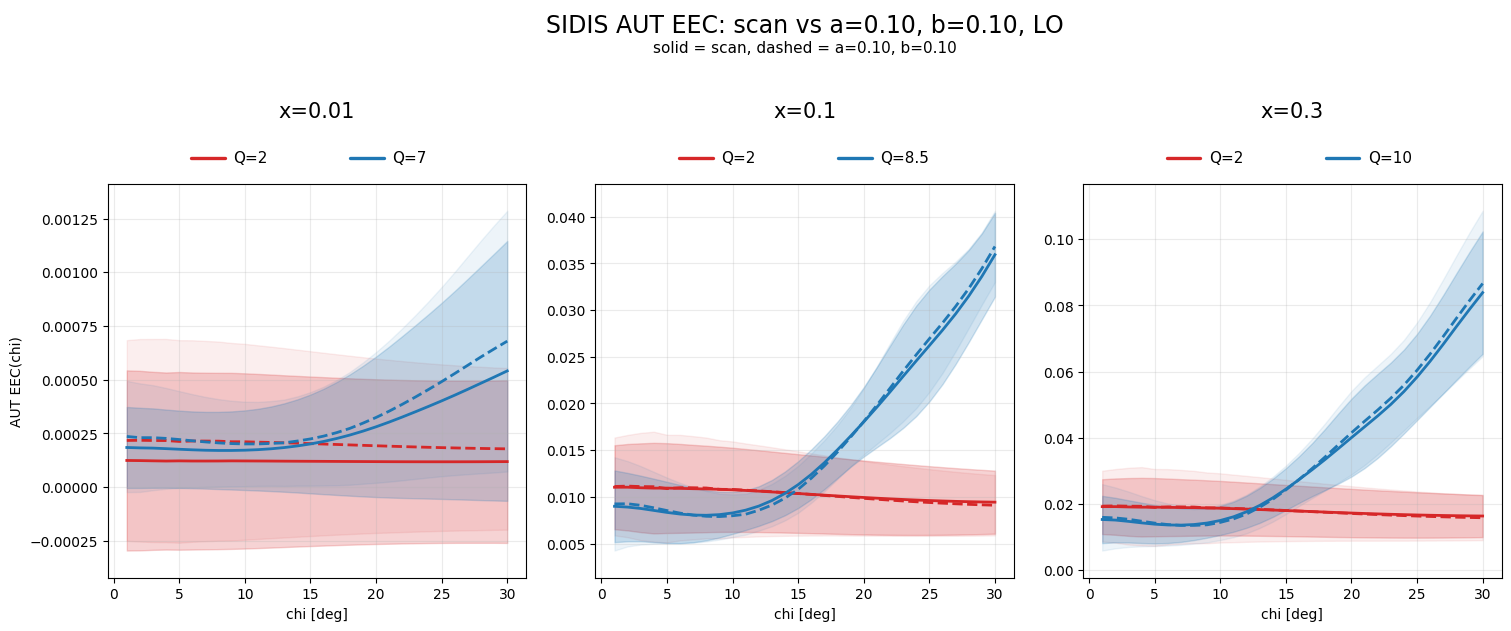

In [4]:
plot_sidis_scan_vs_fixed(
    x_q_map=sidis_x_q_map,
    coeffs=coeffs,
    scan_label=scan_label,
    fit_order=fit_order,
)


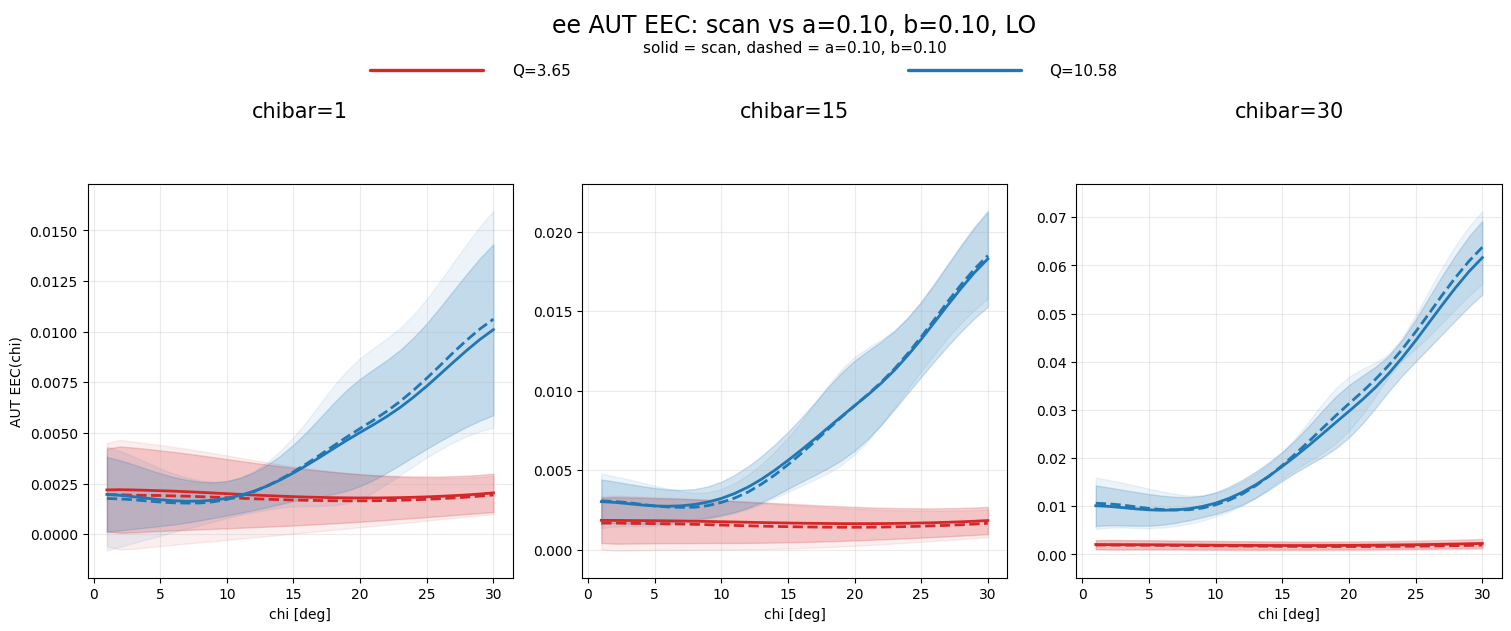

In [5]:
plot_ee_scan_vs_fixed(
    chibar_deg_list=ee_chibar_deg_list,
    Q_list=ee_Q_list,
    coeffs=coeffs,
    scan_label=scan_label,
    fit_order=fit_order,
)
